# 3D Road Network — North Jutland, Denmark

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import gaussian_filter
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND
from load_roads import load_roads_torch

In [23]:
# Load data
# x, y = load_roads_torch(n_sub=50_000)
x, y = load_roads_torch()
x_raw = x.clone()
y_raw = y.clone()
print(f"x shape: {x.shape}")  # (N, 2) — lon, lat
print(f"y shape: {y.shape}")  # (N,) — altitude (m)
print(f"Lon range: {x[:,0].min():.4f} to {x[:,0].max():.4f}")
print(f"Lat range: {x[:,1].min():.4f} to {x[:,1].max():.4f}")
print(f"Altitude range: {y.min():.1f} to {y.max():.1f} m")

x shape: torch.Size([434874, 2])
y shape: torch.Size([434874])
Lon range: 8.1461 to 11.1993
Lat range: 56.5825 to 57.7505
Altitude range: -8.6 to 134.4 m


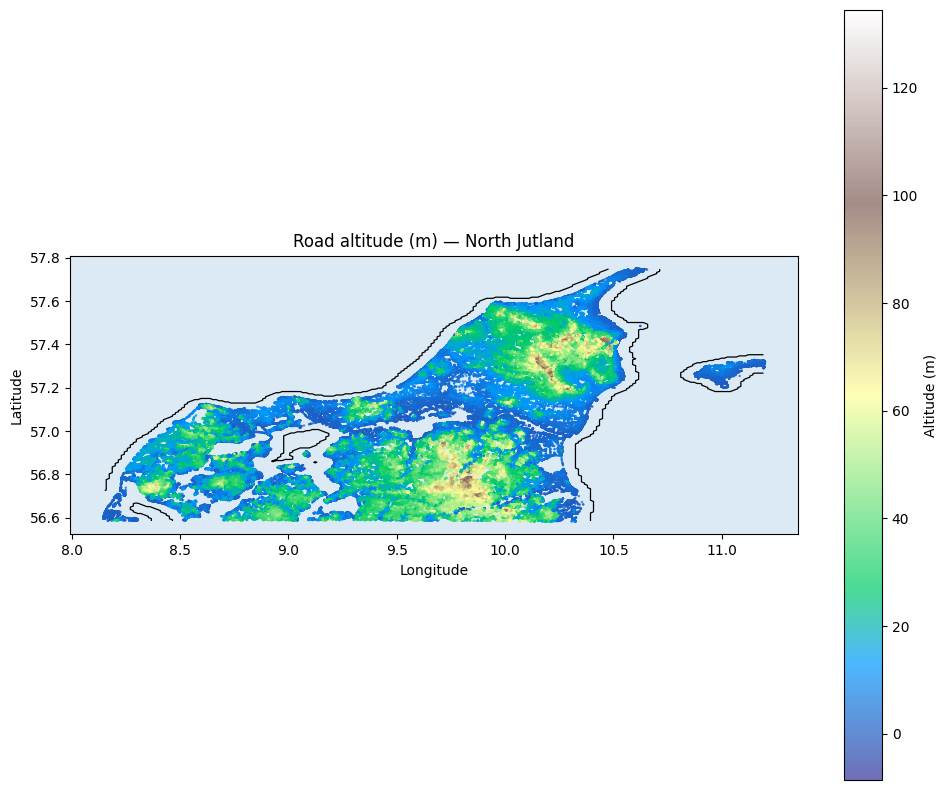

In [24]:
# Derive a coarse coastline/land outline from the road-point density
outline_bins = 220
lon_min_raw, lon_max_raw = float(x_raw[:,0].min()), float(x_raw[:,0].max())
lat_min_raw, lat_max_raw = float(x_raw[:,1].min()), float(x_raw[:,1].max())
outline_counts, outline_lon_edges, outline_lat_edges = np.histogram2d(
    x_raw[:,0].numpy(),
    x_raw[:,1].numpy(),
    bins=outline_bins,
    range=[[lon_min_raw, lon_max_raw], [lat_min_raw, lat_max_raw]],
)
outline_mask = gaussian_filter((outline_counts.T > 0).astype(float), sigma=2.2) > 0.025
outline_lon_centers = 0.5 * (outline_lon_edges[:-1] + outline_lon_edges[1:])
outline_lat_centers = 0.5 * (outline_lat_edges[:-1] + outline_lat_edges[1:])
outline_lon_grid, outline_lat_grid = np.meshgrid(outline_lon_centers, outline_lat_centers)

# Plot raw data
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#dceaf6')
sc = ax.scatter(x_raw[:,0].numpy(), x_raw[:,1].numpy(), c=y_raw.numpy(), s=0.5,
                cmap='terrain', alpha=0.7, rasterized=True)
ax.contour(outline_lon_grid, outline_lat_grid, outline_mask.astype(float), levels=[0.5], colors='black', linewidths=0.9)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Road altitude (m) — North Jutland')
plt.colorbar(sc, ax=ax, label='Altitude (m)')
ax.set_aspect('equal')
plt.tight_layout()

In [4]:
# Normalize inputs to [0, 1] and standardize outputs
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"y mean={y.mean():.4f}, std={y.std():.4f}")

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=-0.0000, std=1.0000


In [11]:
EPSILON = 1e-3
kernel_type = 'Matern52'
cg_tol = 1e-4

In [13]:
max_iters = 50
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.05)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol)
    optimizer.step()

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"iter {it:>3}  ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}")

print(f"Final: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}")

iter   0  ℓ=0.3643  σ_f²=1.051  σ_n²=0.2103
iter  10  ℓ=0.2269  σ_f²=1.62  σ_n²=0.331
iter  20  ℓ=0.1529  σ_f²=2.143  σ_n²=0.4219
iter  30  ℓ=0.1057  σ_f²=2.651  σ_n²=0.4056
iter  40  ℓ=0.07353  σ_f²=3.078  σ_n²=0.3212
Final: ℓ=0.05053, σ_f²=3.166, σ_n²=0.2388


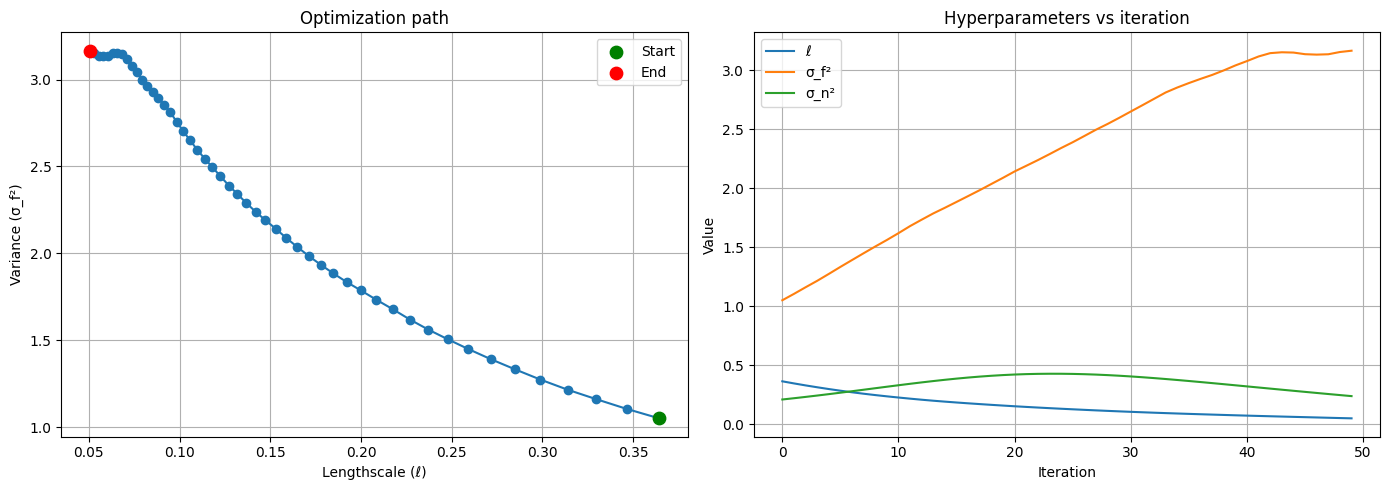

In [14]:
# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ℓ)')
ax1.set_ylabel('Variance (σ_f²)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='ℓ')
ax2.plot(training_log['iter'], training_log['variance'], label='σ_f²')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='σ_n²')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [25]:
# Predict posterior mean on a grid
grid_res = 200
g0 = torch.linspace(0, 1, grid_res, dtype=x.dtype)
g1 = torch.linspace(0, 1, grid_res, dtype=x.dtype)
G0, G1 = torch.meshgrid(g0, g1, indexing='ij')
x_new = torch.stack([G0.flatten(), G1.flatten()], dim=1)

mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

# Inverse transform back to original scales
mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res, grid_res)
lon_grid = (G0.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
lat_grid = (G1.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())

# Mask posterior values outside the inferred land outline
outline_lon_step = outline_lon_centers[1] - outline_lon_centers[0]
outline_lat_step = outline_lat_centers[1] - outline_lat_centers[0]
outline_lon_idx = np.clip(np.rint((lon_grid - outline_lon_centers[0]) / outline_lon_step).astype(int), 0, len(outline_lon_centers) - 1)
outline_lat_idx = np.clip(np.rint((lat_grid - outline_lat_centers[0]) / outline_lat_step).astype(int), 0, len(outline_lat_centers) - 1)
posterior_land_mask = outline_mask[outline_lat_idx, outline_lon_idx]
mean_grid_masked = np.ma.masked_where(~posterior_land_mask, mean_grid)

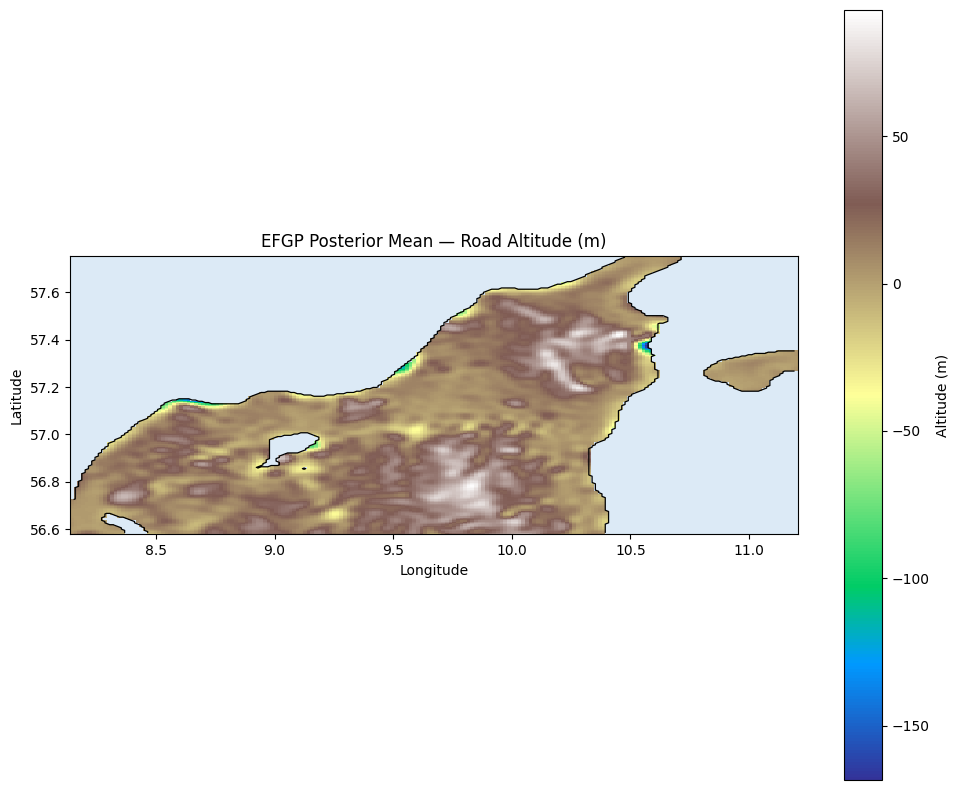

In [26]:
# Plot posterior mean
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#dceaf6')
pcm = ax.pcolormesh(lon_grid, lat_grid, mean_grid_masked, cmap='terrain', shading='auto', rasterized=True)
ax.contour(outline_lon_grid, outline_lat_grid, outline_mask.astype(float), levels=[0.5], colors='black', linewidths=0.9)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('EFGP Posterior Mean — Road Altitude (m)')
plt.colorbar(pcm, ax=ax, label='Altitude (m)')
ax.set_aspect('equal')
plt.tight_layout()